In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# !export PYDEVD_WARN_SLOW_RESOLVE_TIMEOUT=2

### Load packages and data

In [3]:
import spatialdata_io
import matplotlib.pyplot as plt
import spatialdata as sd
import segtraq
import spatialdata_plot
import scanpy as sc
import seaborn as sns
import anndata as ad
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import dask.dataframe as dd
import glob
from dask import delayed

from spatialdata.models import PointsModel
import statsmodels.api as sm
from pathlib import Path
from spatialdata.transformations import (
    get_transformation,
    set_transformation,
)

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
sdata = sd.read_zarr("/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_xenium_crop.zarr/")


In [5]:
st = segtraq.SegTraQ(
    sdata,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No centroids specified for tables. Centroids will be automatically computed from shapes.
  validate_spatialdata(


## Compute baseline metrics

In [6]:
%%time
st.run_baseline()

CPU times: user 1.4 s, sys: 216 ms, total: 1.62 s
Wall time: 1.64 s


## Cosine similarity

In [26]:
st.rs.similarity_center_border()

,similarity_center_border,similarity_center_border_ci_low,similarity_center_border_ci_high,cell_id
0,0.527484,0.414455,0.533441,6327
1,0.505440,0.348386,0.528256,6328
2,0.448379,0.361517,0.478400,6330
3,0.538128,0.414004,0.517761,6331
4,0.549761,0.409466,0.556832,6332
...,...,...,...,...
1558,0.498089,0.394551,0.523047,95953
1559,0.255608,0.054540,0.313346,95954
1560,0.390033,0.236146,0.482259,95955
1561,0.412926,0.173943,0.448639,95959


In [27]:
features = ([
             'similarity_center_border',
             'similarity_center_border_ci_low', 
             'similarity_center_border_ci_high', 
             'transcript_count'])

cell_df = []
obs = sdata.tables['table'].obs[features].copy()
obs['sample'] = "xenium"
cell_df.append(obs)
cell_df = pd.concat(cell_df)
print(cell_df.shape)
cell_df = cell_df.reset_index(drop=True)
cell_df.head()

(1563, 5)


,similarity_center_border,similarity_center_border_ci_low,similarity_center_border_ci_high,transcript_count,sample
0,0.527484,0.414455,0.533441,420.0,xenium
1,0.505440,0.348386,0.528256,201.0,xenium
2,0.448379,0.361517,0.478400,391.0,xenium
3,0.538128,0.414004,0.517761,512.0,xenium
4,0.549761,0.409466,0.556832,345.0,xenium


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

def plot_rs_against_counts(cell_df, xcol, ycols):
    plot_df = cell_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[xcol] + ycols)
    plot_df = plot_df[plot_df[xcol] >= 0]

    n_cols = min(3, len(ycols))
    n_rows = int(np.ceil(len(ycols) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
        sharex=False,
        sharey=False
    )

    # make axes always 2D
    axes = np.atleast_2d(axes)

    for j, ycol in enumerate(ycols):
        i, k = divmod(j, n_cols)
        ax = axes[i, k]

        sns.scatterplot(
            data=plot_df,
            x=xcol,
            y=ycol,
            alpha=0.25,
            s=10,
            linewidth=0,
            ax=ax,
            color="black"
        )

        X = sm.add_constant(plot_df[xcol].to_numpy())
        y = plot_df[ycol].to_numpy()

        if len(X) > 1:
            model = sm.OLS(y, X, missing="drop").fit()
            r2 = model.rsquared

            xs = np.linspace(plot_df[xcol].min(), plot_df[xcol].max(), 200)
            ys = model.predict(sm.add_constant(xs))

            ax.plot(xs, ys, color="red")
            title = f"{ycol}\n$R^2$={r2:.3f}"
        else:
            title = ycol

        ax.set_title(title)

        if i == n_rows - 1:
            ax.set_xlabel(xcol)
        else:
            ax.set_xlabel("")

    # hide unused axes
    total_axes = n_rows * n_cols
    for j in range(len(ycols), total_axes):
        i, k = divmod(j, n_cols)
        axes[i, k].set_visible(False)

    plt.tight_layout()
    plt.show()

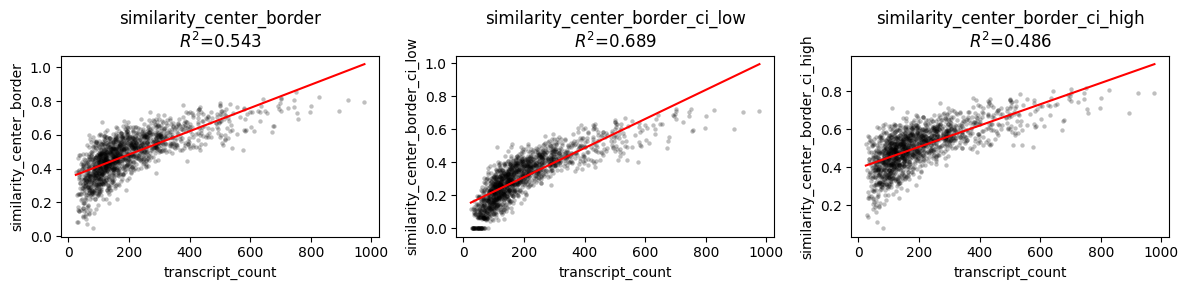

In [29]:
plot_rs_against_counts(cell_df, "transcript_count",
                       ycols=[
                    'similarity_center_border',
                    'similarity_center_border_ci_low', 
                    'similarity_center_border_ci_high', 
                    ])

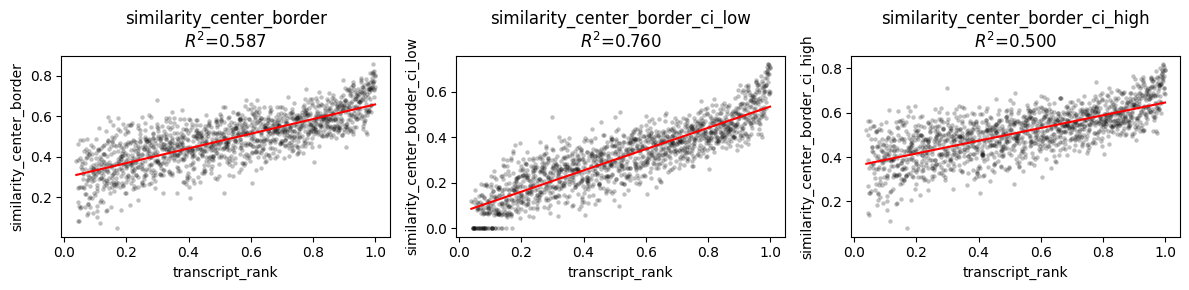

In [30]:
cell_df["transcript_rank"] = cell_df["transcript_count"].rank(pct=True)
plot_rs_against_counts(cell_df, "transcript_rank",
                       ycols=[
                    'similarity_center_border',
                    'similarity_center_border_ci_low', 
                    'similarity_center_border_ci_high', 
                    ])

In [31]:
import numpy as np
import matplotlib.pyplot as plt


def plot_metric_with_confidence_intervals(
    cell_df,
    metric: str = "border_admixture_score",
    figsize: tuple[float, float] = (6, 5),
    markersize: float = 20,
    transcript_count_col: str = "transcript_count",
):
    """
    Scatter plot of observed metric vs transcript rank, with vertical lines showing
    the bootstrap confidence interval.

    Cells where CI_low is above the fitted linear trend are highlighted in red.
    The trend is fit as:

        metric ~ log1p(transcript_count)
    """
    df = cell_df.copy()

    y_col = metric
    q_low_col = f"{metric}_ci_low"
    q_high_col = f"{metric}_ci_high"

    required_cols = [y_col, q_low_col, q_high_col, transcript_count_col]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in DataFrame: {missing}")

    df = df[required_cols].dropna().copy()

    # x-axis for plotting = transcript rank
    df = df.sort_values(transcript_count_col).reset_index(drop=True)
    df["transcript_rank"] = np.arange(1, len(df) + 1)

    x_plot = df["transcript_rank"].to_numpy()
    y = df[y_col].to_numpy()
    q_low = df[q_low_col].to_numpy()
    q_high = df[q_high_col].to_numpy()

    # fit linear regression: metric ~ log1p(transcript_count)
    x_fit = np.log1p(df[transcript_count_col].to_numpy(dtype=float))
    slope, intercept = np.polyfit(x_fit, y, 1)
    y_fit = intercept + slope * x_fit

    # flag cells whose CI lower bound is above expected value from regression
    flagged = q_high < y_fit
    not_flagged = ~flagged

    fig, ax = plt.subplots(figsize=figsize)

    # CI bars
    ax.vlines(
        x=x_plot[not_flagged],
        ymin=q_low[not_flagged],
        ymax=q_high[not_flagged],
        alpha=0.2,
        linewidth=0.8,
    )
    ax.vlines(
        x=x_plot[flagged],
        ymin=q_low[flagged],
        ymax=q_high[flagged],
        alpha=0.6,
        color="red",
        linewidth=1.0,
    )

    # observed points
    ax.scatter(
        x_plot[not_flagged],
        y[not_flagged],
        alpha=0.4,
        s=markersize,
        label="others",
    )
    ax.scatter(
        x_plot[flagged],
        y[flagged],
        alpha=0.9,
        s=markersize,
        color="red",
        label="CI_high < fitted trend",
    )

    # draw fitted line in transcript-rank order
    order = np.argsort(x_plot)
    ax.plot(
        x_plot[order],
        y_fit[order],
        linestyle="--",
        linewidth=1,
        label=f"linear fit vs log1p({transcript_count_col})",
    )

    ax.set_xlabel("Transcript rank")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} with confidence intervals\n(red: CI_high < fitted trend)")
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

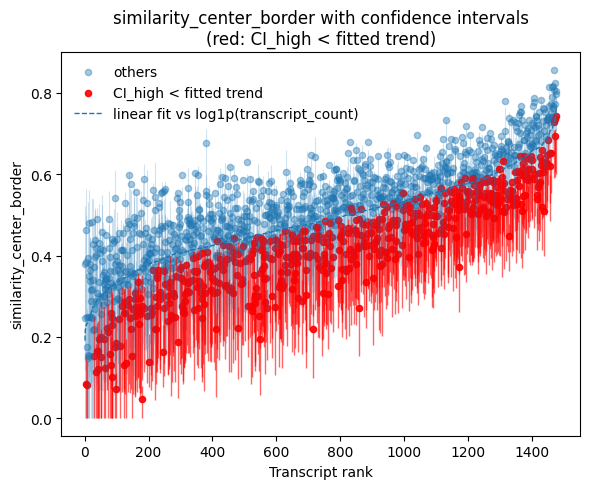

In [32]:
plot_metric_with_confidence_intervals(
    cell_df=cell_df,
    metric="similarity_center_border",
    transcript_count_col="transcript_count",
)

## Spatial visualizations

In [33]:
adata_ref = ad.read_h5ad("../../data/BC_scRNAseq_Janesick.h5ad")

In [34]:
st.run_label_transfer(
        adata_ref, ref_cell_type="celltype_major", inplace=True, ref_ensemble_key=None, query_ensemble_key=None
    )

/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:234: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:771: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.Raw counts will be stored in `adata_q.layers["counts"]`.
  result = _run_label_transfer(


In [35]:
# Define color palette for plotting
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080",
}

In [36]:
# Replace NaN with Unknown for plotting

s = st.sdata.tables["table"].obs["transferred_cell_type"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

st.sdata.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

/tmp/ipykernel_2544988/3220636980.py:4: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):


In [21]:
def plot_feature_labels(sdata, method, feature, axes):
    labels = sdata.tables["table"].obs["transferred_celltype_plot"].unique().astype(str).tolist()
    cols = [col_celltype[lab] for lab in labels]

    sdata.tables["table"].obs["region"] = "cell_boundaries"
    sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

    sdata.pl.render_shapes(
        "cell_boundaries",
        color="transferred_celltype_plot",
        palette=cols,
        groups=labels,
        outline_color="white",
        outline_width=0.5,
    ).pl.show(ax=axes[0], title=f"{method}:Cell boundaries colored by cell type", coordinate_systems="global")

    sdata.pl.render_shapes(
        "cell_boundaries",
        color=feature,
        outline_color="white",
        outline_width=0.5,
    ).pl.show(ax=axes[1], title=f"{method}: {feature}", coordinate_systems="global")

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:481: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


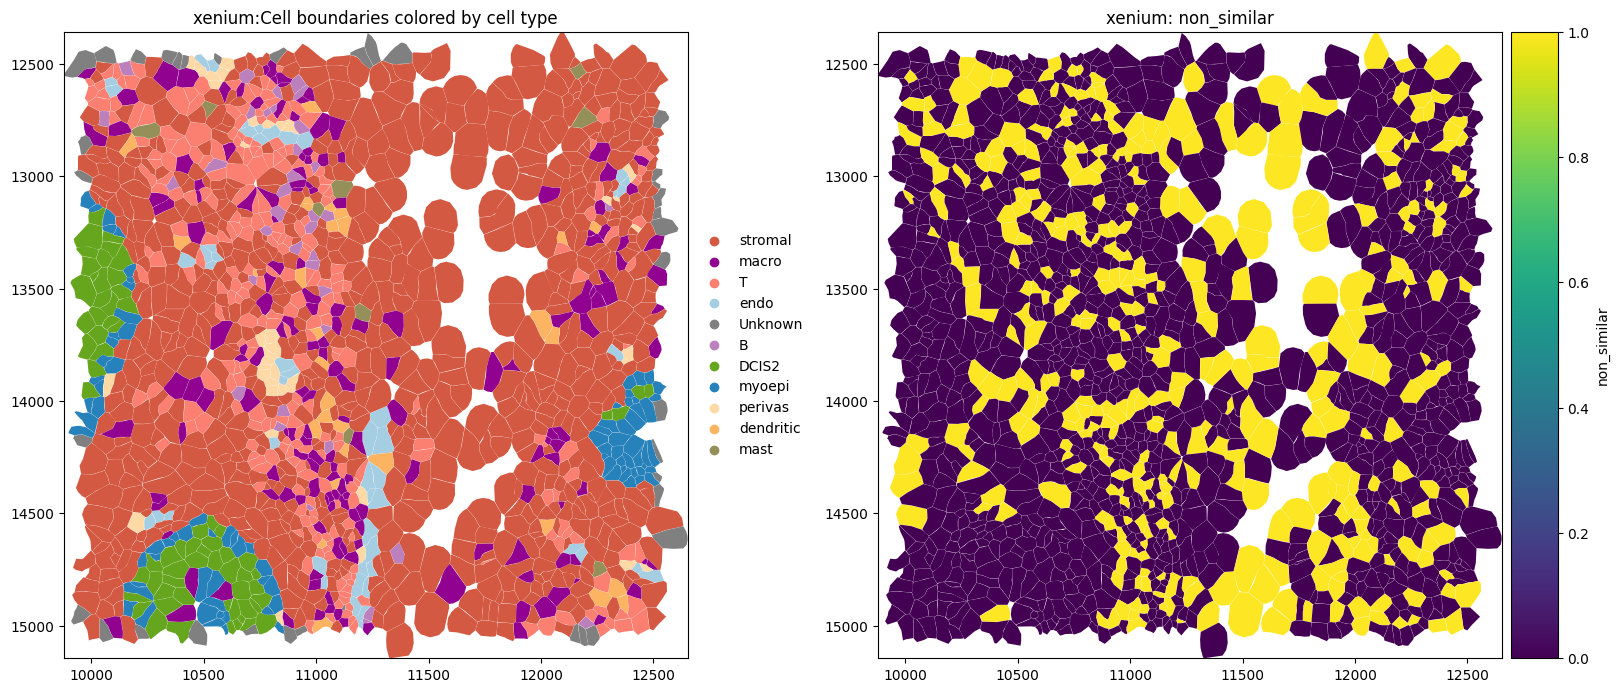

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10), constrained_layout=True)
obs = st.sdata.tables["table"].obs

# fit linear regression: metric ~ log1p(transcript_count)
x_fit = np.log1p(obs["transcript_count"].to_numpy(dtype=float))
y = obs["similarity_center_border"].to_numpy(dtype=float)

mask = np.isfinite(x_fit) & np.isfinite(y)

slope, intercept = np.polyfit(x_fit[mask], y[mask], 1)
y_fit = intercept + slope * x_fit

x_fit = np.log1p(obs["transcript_count"].to_numpy(dtype=float))

q_high = obs["similarity_center_border_ci_high"].to_numpy(dtype=float)

# flag cells whose CI upper bound is below expected value from regression
st.sdata.tables["table"].obs["similarity_center_border_residual"] = y - y_fit
st.sdata.tables["table"].obs["non_similar"] = (q_high < y_fit) & (st.sdata.tables["table"].obs["similarity_center_border_residual"] < -0.05)

plot_feature_labels(st.sdata, "xenium", "non_similar", axes)

In [55]:
import math

from segtraq.rs.utils import _get_center_border_counts, _compute_ncvs_within_radius


def _normalize_with_pseudocount(x: np.ndarray, pseudocount: float = 0.5) -> np.ndarray:
    x = np.asarray(x, dtype=float).ravel()
    x = x + pseudocount
    total = x.sum()
    if total <= 0:
        return np.zeros_like(x, dtype=float)
    return x / total


def _get_top_genes_for_cell(
    sdata,
    cid,
    n_genes: int = 6,
    mode: str = "absolute",  # "absolute", "neighborhood_vs_center", "both_directions"
    tables_key: str = "table",
    cell_id_key: str = "cell_id",
    expr_center_raw: pd.DataFrame | None = None,
    expr_neighborhood_raw: pd.DataFrame | None = None,
    pseudocount: float = 0.5,
):
    """
    Select top genes for one cell.

    Parameters
    ----------
    mode : str
        "absolute":
            top genes by absolute whole-cell counts

        "neighborhood_vs_center":
            top genes with largest (p_neighborhood - p_center)

        "both_directions":
            balanced set of genes from both directions:
            - top genes with largest (p_neighborhood - p_center)
            - top genes with largest (p_center - p_neighborhood)
    """
    obs = sdata[tables_key].obs
    mask = obs[cell_id_key] == cid
    if mask.sum() == 0:
        return []

    if mode == "absolute":
        adata_sub = sdata[tables_key][mask, :]
        X = adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else np.asarray(adata_sub.X)
        expr_vector = np.asarray(X).ravel()

        nonzero = expr_vector > 0
        if nonzero.sum() == 0:
            return []

        genes_nonzero = adata_sub.var_names[nonzero]
        expr_nonzero = expr_vector[nonzero]

        return (
            pd.Series(expr_nonzero, index=genes_nonzero)
            .sort_values(ascending=False)
            .head(n_genes)
            .index
            .tolist()
        )

    if mode in {"neighborhood_vs_center", "both_directions"}:
        if expr_center_raw is None or expr_neighborhood_raw is None:
            raise ValueError(
                "`expr_center_raw` and `expr_neighborhood_raw` must be provided "
                f"for mode={mode!r}."
            )

        if cid not in expr_center_raw.index or cid not in expr_neighborhood_raw.index:
            return []

        common_genes = expr_center_raw.columns.intersection(expr_neighborhood_raw.columns)
        if len(common_genes) == 0:
            return []

        x_center = expr_center_raw.loc[cid, common_genes].to_numpy(dtype=float)
        x_neighborhood = expr_neighborhood_raw.loc[cid, common_genes].to_numpy(dtype=float)

        p_center = _normalize_with_pseudocount(x_center, pseudocount=pseudocount)
        p_neighborhood = _normalize_with_pseudocount(x_neighborhood, pseudocount=pseudocount)

        delta = pd.Series(p_neighborhood - p_center, index=common_genes)

        # keep only genes present in at least one of the two profiles
        keep = (x_center + x_neighborhood) > 0
        delta = delta[keep]
        if delta.empty:
            return []

        if mode == "neighborhood_vs_center":
            return delta.sort_values(ascending=False).head(n_genes).index.tolist()

        if mode == "both_directions":
            n_up = int(np.ceil(n_genes / 2))
            n_down = int(np.floor(n_genes / 2))

            genes_up = delta.sort_values(ascending=False).head(n_up).index.tolist()
            genes_down = delta.sort_values(ascending=True).head(n_down).index.tolist()

            # remove duplicates while preserving order
            genes = []
            for g in genes_up + genes_down:
                if g not in genes:
                    genes.append(g)

            return genes

    raise ValueError(
        "`mode` must be 'absolute', 'neighborhood_vs_center', or 'both_directions'."
    )


def plot_cell_with_metric_and_genes(
    sdata,
    cid,
    feature: str,
    genes: list[str] | None = None,
    title: str | None = None,
    palette: list[str] | None = None,
    pix_to_um_scale_factor: float = 0.2125,
    repositioned_transcripts: bool = False,
    padding: float = 200,
    center_layer: str = "cell_centers",
    outer_layer: str = "cell_boundaries",
    tables_key: str = "table",
    points_key: str = "transcripts",
    cell_id_key: str = "cell_id",
    gene_key: str = "feature_name",
    ax=None,
):
    """
    Plot one focal cell, color shapes by `feature`, and overlay selected transcripts.
    """
    if cid not in sdata[outer_layer].index:
        raise KeyError(f"Cell id {cid} not found in `{outer_layer}`.")

    centroid_x_cell_px = sdata[outer_layer].loc[cid].geometry.centroid.x
    centroid_y_cell_px = sdata[outer_layer].loc[cid].geometry.centroid.y

    centroid_x_cell = centroid_x_cell_px / pix_to_um_scale_factor
    centroid_y_cell = centroid_y_cell_px / pix_to_um_scale_factor

    trans = sdata.points[points_key].compute().copy()
    trans["focal_cell"] = "other_cells"
    trans.loc[trans[cell_id_key] == cid, "focal_cell"] = "focal_cell"
    trans["focal_cell"] = trans["focal_cell"].astype("category")

    temp_points_key = "transcripts__temp_plot"

    if repositioned_transcripts:
        trans = trans.drop(columns=["x", "y", "z"], errors="ignore")
        trans = trans.rename(
            columns={
                "repositioned_x": "x",
                "repositioned_y": "y",
                "repositioned_z": "z",
            }
        )

    sdata.points[temp_points_key] = sd.models.PointsModel.parse(trans)
    T = sd.transformations.get_transformation(sdata.points[points_key])
    sd.transformations.set_transformation(sdata.points[temp_points_key], T)

    sdata_cropped = sdata.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[centroid_x_cell - padding, centroid_y_cell - padding],
        max_coordinate=[centroid_x_cell + padding, centroid_y_cell + padding],
        target_coordinate_system="global",
    )

    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(8, 8), constrained_layout=True)

    plot = (
        sdata_cropped.pl.render_shapes(
            element=center_layer,
            fill_alpha=0.2,
            outline_alpha=1.0,
            outline_width=0.5,
            outline_color="black",
        )
        .pl.render_shapes(
            element=outer_layer,
            color=feature,
            fill_alpha=0.4,
            outline_alpha=1.0,
            outline_width=0.7,
            outline_color="blue",
        )
    )

    if genes is None or len(genes) == 0:
        plot = plot.pl.render_points(
            temp_points_key,
            color="focal_cell",
            fill_alpha=0.2,
            size=4.0,
            groups=["focal_cell"],
            palette=["red"],
        )
    else:
        if palette is None:
            base_palette = ([
            "#054907",  # blue
            "#25B01A",  # lighter blue
            "#BBF90F",  # pale sky blue

            "#ED0DD9",  # purple
            "#FF0000",  # dusty pink
            "#F97306",  # rose pink

            "#8c564b",  # brown
            "#7f7f7f",  # gray
            "#bcbd22",  # olive
            "#4c9ed9",  # cyan
        ])
            palette = [base_palette[i % len(base_palette)] for i in range(len(genes))]

        plot = plot.pl.render_points(
            temp_points_key,
            color=gene_key,
            fill_alpha=0.7,
            groups=genes,
            size=4.0,
            palette=palette,
        )

    plot.pl.show(
        ax=ax,
        title=title if title is not None else f"Cell {cid}",
        colorbar=True,
    )

    ax.scatter(
        [centroid_x_cell],
        [centroid_y_cell],
        marker="+",
        s=400,
        c="black",
        linewidths=2,
        zorder=10,
        alpha=0.4,
    )


def plot_top_cells_by_metric(
    sdata,
    feature: str,
    ascending: bool = False,
    n_cells: int = 6,
    n_genes: int = 5,
    cell_mask: pd.Series | None = None,
    gene_selection_mode: str = "neighborhood_vs_center",  # "absolute" or "neighborhood_vs_center"
    tables_key: str = "table",
    cell_id_key: str = "cell_id",
    points_key: str = "transcripts",
    gene_key: str = "feature_name",
    center_layer: str = "cell_centers",
    outer_layer: str = "cell_boundaries",
    pix_to_um_scale_factor: float = 0.2125,
    repositioned_transcripts: bool = False,
    padding: float = 200,
    skip_first: int = 0,
    palette: list[str] | None = None,
    figsize_per_panel: tuple[float, float] = (8, 6),
    pseudocount: float = 0.5,
    # parameters used only if gene_selection_mode == "neighborhood_vs_center"
    shapes_key: str = "cell_boundaries",
    points_background_id: str = "UNASSIGNED",
    points_x_key: str = "x",
    points_y_key: str = "y",
    erosion_fraction_of_radius: float = 0.2,
    neighborhood_radius_factor: float = 2.0,
):
    """
    Plot the top `n_cells` cells ranked by `feature`.

    For each selected cell:
    - color the cell boundaries by `feature`
    - overlay transcripts of selected genes
    - show cell_id and metric value in the title

    Gene selection modes
    --------------------
    absolute:
        top genes by absolute whole-cell counts

    neighborhood_vs_center:
        top genes with largest (p_neighborhood - p_center) for that cell,
        using precomputed center and neighborhood count matrices
    """
    obs = sdata[tables_key].obs.copy()

    if cell_mask is not None:
        obs = obs.loc[cell_mask, :]

    if feature not in obs.columns:
        raise KeyError(f"`{feature}` not found in `sdata[{tables_key!r}].obs`.")
    if cell_id_key not in obs.columns:
        raise KeyError(f"`{cell_id_key}` not found in `sdata[{tables_key!r}].obs`.")

    df_rank = (
        obs[[cell_id_key, feature]]
        .dropna()
        .sort_values(feature, ascending=ascending)
        .iloc[skip_first: skip_first + n_cells]
        .copy()
    )

    if df_rank.empty:
        raise ValueError(f"No cells available to plot for feature `{feature}`.")

    selected_cell_ids = df_rank[cell_id_key].tolist()

    expr_center_raw = None
    expr_neighborhood_raw = None

    if gene_selection_mode == "neighborhood_vs_center" or gene_selection_mode == "both_directions":
        expr_center_raw, _ = _get_center_border_counts(
            sdata=sdata,
            tables_key=tables_key,
            tables_cell_id_key=cell_id_key,
            shapes_key=shapes_key,
            points_key=points_key,
            points_cell_id_key=cell_id_key,
            points_background_id=points_background_id,
            points_x_key=points_x_key,
            points_y_key=points_y_key,
            points_gene_key=gene_key,
            erosion_fraction_of_radius=erosion_fraction_of_radius,
        )

        expr_neighborhood_raw = _compute_ncvs_within_radius(
            sdata=sdata,
            tables_key=tables_key,
            tables_cell_id_key=cell_id_key,
            shapes_key=shapes_key,
            neighborhood_radius_factor=neighborhood_radius_factor,
        )

    n_panels = len(selected_cell_ids)
    ncols = min(3, n_panels)
    nrows = math.ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, cid in zip(axes, selected_cell_ids):
        metric_value = df_rank.loc[df_rank[cell_id_key] == cid, feature].iloc[0]

        genes = _get_top_genes_for_cell(
            sdata=sdata,
            cid=cid,
            n_genes=n_genes,
            mode=gene_selection_mode,
            tables_key=tables_key,
            cell_id_key=cell_id_key,
            expr_center_raw=expr_center_raw,
            expr_neighborhood_raw=expr_neighborhood_raw,
            pseudocount=pseudocount,
        )

        title = (
            f"cell_id={cid}\n"
            f"{feature}={metric_value:.3g}\n"
            f"gene mode: {gene_selection_mode}\n"
            f"top genes: {', '.join(genes) if len(genes) > 0 else 'none'}"
        )

        plot_cell_with_metric_and_genes(
            sdata=sdata,
            cid=cid,
            feature=feature,
            genes=genes,
            title=title,
            palette=palette,
            pix_to_um_scale_factor=pix_to_um_scale_factor,
            repositioned_transcripts=repositioned_transcripts,
            padding=padding,
            center_layer=center_layer,
            outer_layer=outer_layer,
            tables_key=tables_key,
            points_key=points_key,
            cell_id_key=cell_id_key,
            gene_key=gene_key,
            ax=ax,
        )

    for ax in axes[len(selected_cell_ids):]:
        ax.axis("off")

    return fig, axes[:len(selected_cell_ids)]

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  Found 6 NaN values in color data. These observations will be colored with the 'na_color'.                 
WARNING  No table name provided, using 'table' as fallback for color mapping.                                      
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:928: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.

WARNING  Found 6 NaN values in color data. These observations will be colored with the 'na_color'.                 
WARNING  No table name provided, using 'table' as fallback for color mapping.                                      
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:928: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.

...

WARNING  Found 9 NaN values in color data. These observations will be colored with the 'na_color'.                 
WARNING  No table name provided, using 'table' as fallback for color mapping.                                      
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:928: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.

WARNING  No table name provided, using 'table' as fallback for color mapping.                                      
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:928: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.

(<Figure size 2400x1800 with 18 Axes>,
 array([<Axes: title={'center': 'cell_id=77205\nsimilarity_center_border_residual=-0.324\ngene mode: both_directions\ntop genes: LYZ, SLAMF7, PTPRC, CCDC80, CXCL12, PTGDS'}>,
        <Axes: title={'center': 'cell_id=95304\nsimilarity_center_border_residual=-0.26\ngene mode: both_directions\ntop genes: LUM, POSTN, CXCL12, CXCR4, CCL5, CD8B'}>,
        <Axes: title={'center': 'cell_id=95795\nsimilarity_center_border_residual=-0.26\ngene mode: both_directions\ntop genes: SEC11C, ERBB2, MMP2, MRC1, VOPP1, ZEB2'}>,
        <Axes: title={'center': 'cell_id=77039\nsimilarity_center_border_residual=-0.258\ngene mode: both_directions\ntop genes: POSTN, PTGDS, MMP2, SMAP2, CXCL12, PIM1'}>,
        <Axes: title={'center': 'cell_id=77315\nsimilarity_center_border_residual=-0.24\ngene mode: both_directions\ntop genes: TOMM7, ERBB2, DST, GPR183, KLRB1, PTPRC'}>,
        <Axes: title={'center': 'cell_id=94091\nsimilarity_center_border_residual=-0.236\ngene mode:

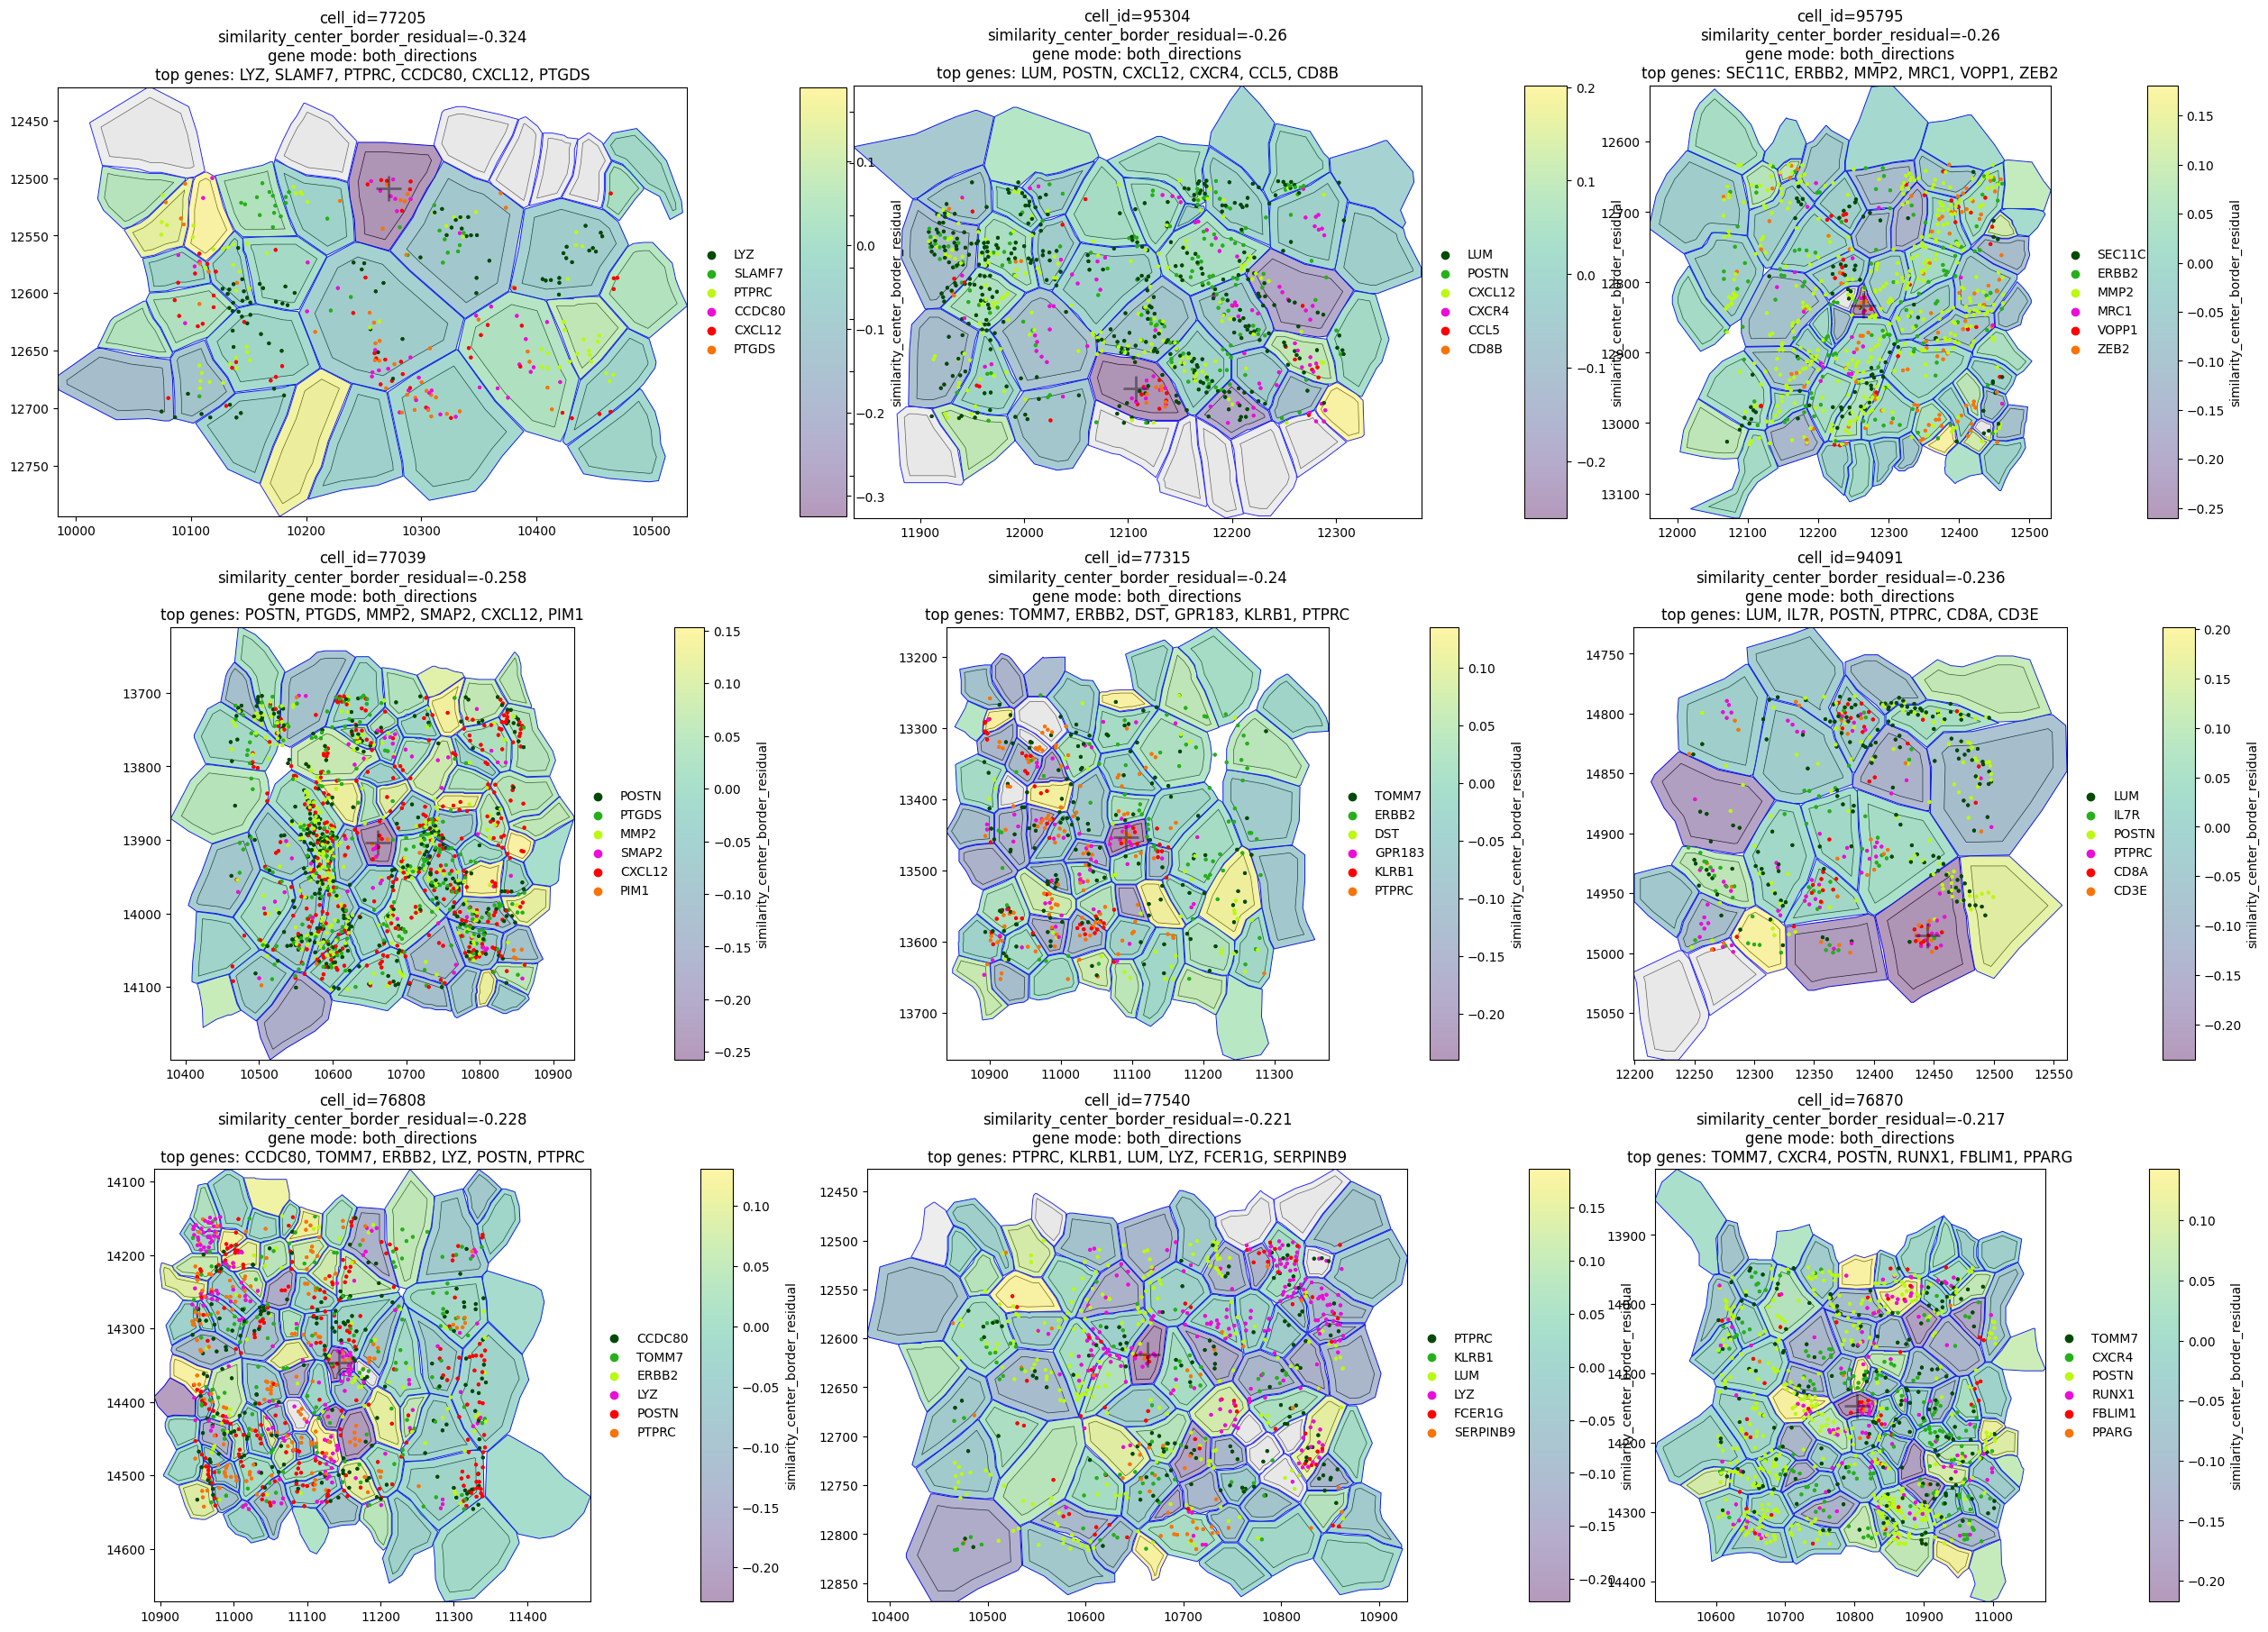

In [56]:
obs = sdata.tables['table'].obs
cell_mask = (
    obs['non_similar'] == True
)

plot_top_cells_by_metric(
    sdata,
    cell_mask = cell_mask,
    feature="similarity_center_border_residual",
    ascending=True,
    gene_selection_mode="both_directions",
    n_cells=9,
    n_genes=6,
    padding=200,
)

## Comparison of border admixture score for Xenium v1 (480 genes) and for Xenium Prime (5k genes) dataset

In [63]:
sdata_xenium = sd.read_zarr("/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_xenium_crop.zarr")
sdata_proseg2 = sd.read_zarr("/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_proseg_v2_crop.zarr/")
sdata_proseg3 = sd.read_zarr("/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_proseg_v3_crop.zarr/")

In [64]:
st_xenium = segtraq.SegTraQ(
    sdata_xenium,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

st_proseg2 = segtraq.SegTraQ(
    sdata_proseg2,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

st_proseg3 = segtraq.SegTraQ(
    sdata_proseg3,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No centroids specified for tables. Centroids will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(


In [65]:
st_xenium.filter_control_and_low_quality_transcripts()
st_proseg2.filter_control_and_low_quality_transcripts()
st_proseg3.filter_control_and_low_quality_transcripts(min_qv=None)

In [66]:
st_dict = {"xenium": st_xenium, "proseg2": st_proseg2, "proseg3": st_proseg3}

In [67]:
for method, st in st_dict.items():

    _mix_fit = st.rs.border_admixture_score(neighborhood_radius_factor=0.5)

In [68]:
def density_plot_feature(sdata_dict, features):
    all_feats = []
    for method, st in sdata_dict.items():
        feat = st.sdata["table"].obs[features]
        tmp = feat.copy()
        tmp["method"] = method
        all_feats.append(tmp)

    df = pd.concat(all_feats, ignore_index=True)
    df["method"] = df["method"].astype(str)

    feature_cols = [c for c in df.columns if c != "method"]

    plt.style.use("default")

    n = len(feature_cols)
    n_cols = min(3, n)
    n_rows = np.ceil(n / n_cols).astype(int)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 2 * n_rows),
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, feat in zip(axes, feature_cols, strict=False):
        sns.kdeplot(data=df, x=feat, hue="method", common_norm=False, palette="Set2", fill=False, ax=ax)

    fig.tight_layout()
    plt.show()

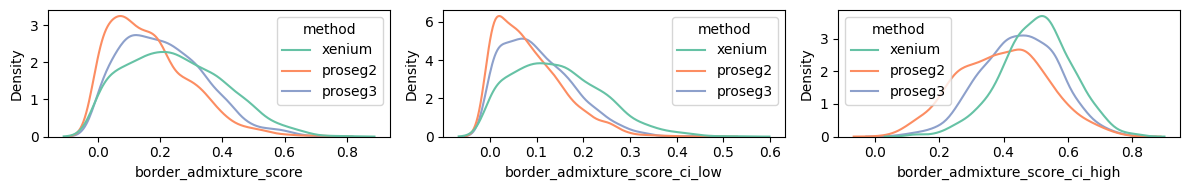

In [69]:
features = ["border_admixture_score", "border_admixture_score_ci_low", "border_admixture_score_ci_high"]
density_plot_feature(st_dict, features)

In [ ]:
print(f"NaNs in Xenium: {st_xenium.sdata.tables['table'].obs['border_admixture_score'].notna().sum()}")
print(f"NaNs in Proseg2: {st_proseg2.sdata.tables['table'].obs['border_admixture_score'].notna().sum()}")
print(f"NaNs in ProSeg3: {st_proseg3.sdata.tables['table'].obs['border_admixture_score'].notna().sum()}")

NaNs in Xenium: 1447
NaNs in Proseg2: 1322
NaNs in ProSeg3: 1269


In [71]:
sdata_xenium_ws = sd.read_zarr("../../data/xenium.zarr")
sdata_bidcell_ws = sd.read_zarr("../../data/bidcell.zarr")
sdata_proseg_ws = sd.read_zarr("../../data/proseg2.zarr")

no parent found for <ome_zarr.reader.Label object at 0x7ffdb07f5390>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffdc88355d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffdb2946150>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffd59863390>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffd587db4d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffdb01350d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffd587b0a10>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffdb0be3890>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffdb0133a90>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffd587ef5d0>: None


In [72]:
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [73]:
def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )


sdata_xenium = crop(sdata_xenium_ws)
sdata_bidcell = crop(sdata_bidcell_ws)
sdata_proseg = crop(sdata_proseg_ws)

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from perfo

In [74]:
st_xenium = segtraq.SegTraQ(
    sdata_xenium, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid"
)
st_bidcell = segtraq.SegTraQ(
    sdata_bidcell,
    images_key="image",
    points_background_id=0,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)
st_proseg = segtraq.SegTraQ(
    sdata_proseg,
    images_key="image",
    points_background_id=0,
    tables_area_key=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:1346: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: UserWarning: points_background_id '0' is not the most common cell ID among points (most common is '2022'). This may indicate that your background ID is not correctly set. If you are sure that 'points_background_id' is correct, you can ignore this warning.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:1346: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes

In [75]:
st_dict = {"xenium": st_xenium, "bidcell": st_bidcell, "proseg": st_proseg}

In [76]:
for _, st in st_dict.items():
    st.filter_control_and_low_quality_transcripts(min_qv=20)

In [77]:
for method, st in st_dict.items():

    _mix_fit = st.rs.border_admixture_score(neighborhood_radius_factor=0.5)

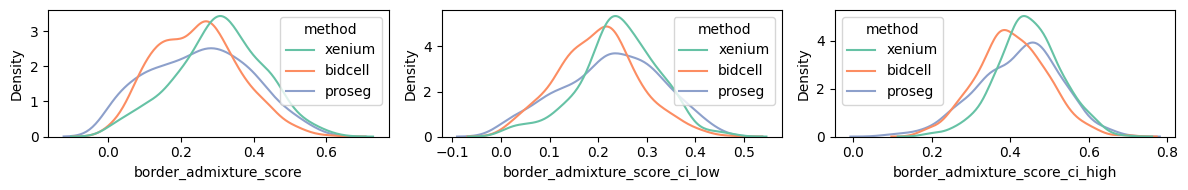

In [78]:
features = ["border_admixture_score", "border_admixture_score_ci_low", "border_admixture_score_ci_high"]
density_plot_feature(st_dict, features)

In [ ]:
print(f"NaNs in Xenium: {st_xenium.sdata.tables['table'].obs['border_admixture_score'].notna().sum()}")
print(f"NaNs in BidCell: {st_bidcell.sdata.tables['table'].obs['border_admixture_score'].notna().sum()}")
print(f"NaNs in ProSeg: {st_proseg.sdata.tables['table'].obs['border_admixture_score'].notna().sum()}")

NaNs in Xenium: 567
NaNs in BidCell: 557
NaNs in ProSeg: 436


In [80]:
print(f"NaNs in Xenium: {st_xenium.sdata.tables['table'].obs['border_admixture_score'].isna().sum()}")
print(f"NaNs in BidCell: {st_bidcell.sdata.tables['table'].obs['border_admixture_score'].isna().sum()}")
print(f"NaNs in ProSeg: {st_proseg.sdata.tables['table'].obs['border_admixture_score'].isna().sum()}")

NaNs in Xenium: 184
NaNs in BidCell: 203
NaNs in ProSeg: 309
